# General notebook

In [18]:
using Revise
Revise.retry() # Just in case if only Revise is not sufficient. 
include("lattice_protein.jl")

Imports done, importing hamiltonian path
hamiltonian path imported, importing metropolis
metropolis imported, importing benchmark
benchmark imported, importing visualization
visualization imported, importing tree
tree imported, importing lattice_protein


## Hamiltonian paths

In [2]:
println("We find $(length(PATHS)) unique paths.")
println(first(PATHS))

We find 103346 unique paths.
Int8[1, 2, 3, 6, 5, 4, 7, 8, 9, 18, 17, 16, 13, 14, 15, 12, 11, 10, 19, 20, 21, 24, 23, 22, 25, 26, 27]


Contact map for the first path:
Path visualization for the 75005:


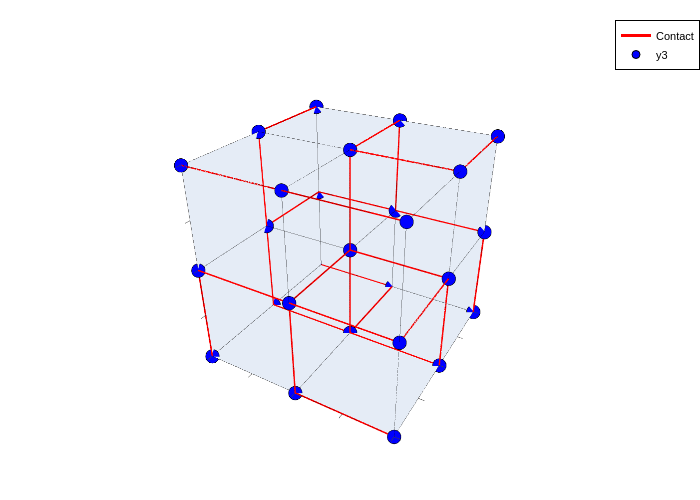

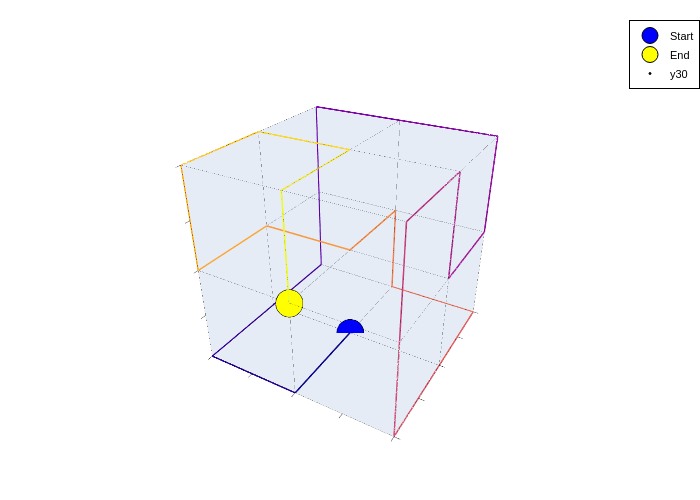

In [3]:
println("Contact map for the first path:")
liste_contact = contact_map(PATHS[75005])
display(plot_cube_ctc_map(x, y, z, lx, ly, lz, liste_contact))

println("Path visualization for the 75005:")
display(plot_cube_path(x, y, z, lx, ly, lz, PATHS[75005]))

## Metropolis general results

Attention : si on veut changer de matrice (MJ*5 ou MJ_1996) il faut restart le kernel et modifier la ligne const dans le ficher metropolis.jl. 

MJ*5

algo (β=100) 100%|███████████████████████████████████████| Time: 0:01:15


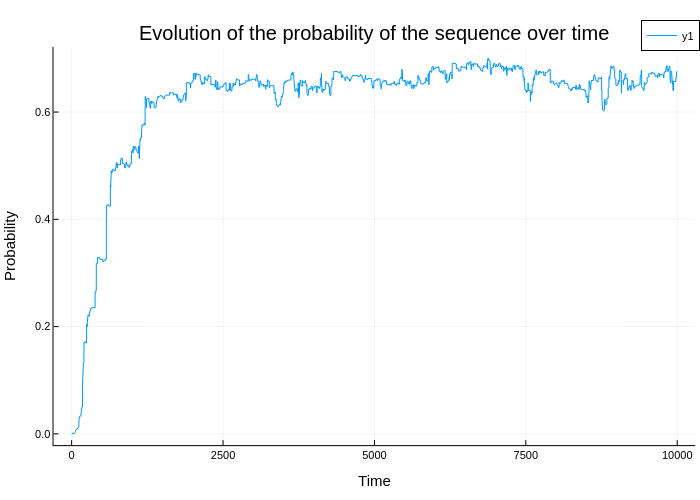

In [4]:
# with all the data
seq = generate_seq()
print(matrix_name)
target_number = 75005
all_ctc_maps = all_contact_maps(PATHS)
plot_probability(seq, target_number, all_ctc_maps, 10000)

MJ*5

algo (β=100) 100%|███████████████████████████████████████| Time: 0:00:06


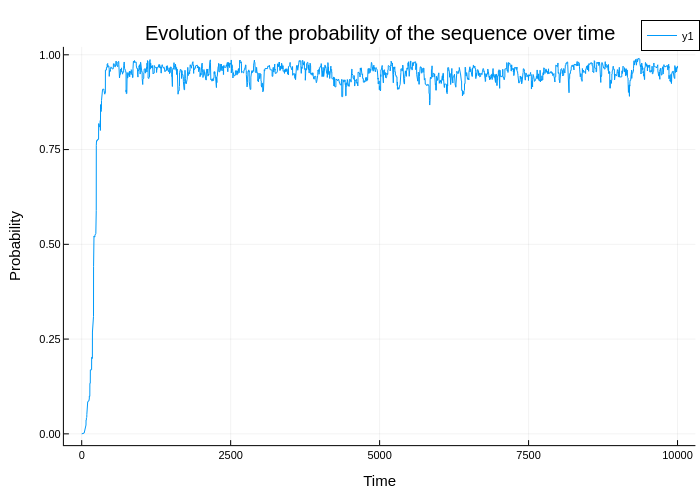

In [5]:
# with few data
paths_reduced = reduce_data(PATHS, 10)
seq = generate_seq()
target_number = 1234
print(matrix_name)

all_ctc_maps = all_contact_maps(paths_reduced)
plot_probability(seq, target_number, all_ctc_maps, 10000)

Testing beta = 10


algo (β=10) 100%|████████████████████████████████████████| Time: 0:00:02


Testing beta = 50


algo (β=50) 100%|████████████████████████████████████████| Time: 0:00:02


Testing beta = 100


algo (β=100) 100%|███████████████████████████████████████| Time: 0:00:02


Testing beta = 1000


algo (β=1000) 100%|██████████████████████████████████████| Time: 0:00:02


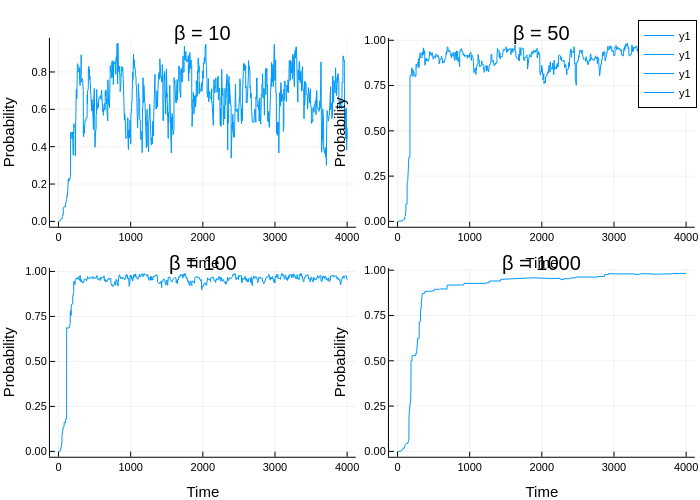

Dict{Float64, Tuple{Vector{Int64}, Vector{Float64}}} with 4 entries:
  50.0   => ([3, 16, 7, 6, 19, 15, 3, 16, 16, 17  …  18, 15, 16, 11, 15, 1, 8, …
  10.0   => ([17, 2, 19, 11, 6, 16, 17, 9, 4, 18  …  5, 17, 19, 16, 15, 4, 12, …
  1000.0 => ([16, 19, 9, 19, 16, 3, 15, 10, 19, 17  …  16, 3, 18, 16, 16, 15, 3…
  100.0  => ([4, 3, 20, 19, 12, 4, 16, 2, 16, 10  …  18, 1, 18, 15, 2, 15, 6, 3…

In [6]:
paths_reduced = reduce_data(PATHS, 10)
seq = generate_seq()
target_number = 1234
all_ctc_maps = all_contact_maps(paths_reduced)


benchmark_beta()

## Further observations

### Chain evolution

ici

Multi-init 100%|█████████████████████████████████████████| Time: 0:00:21


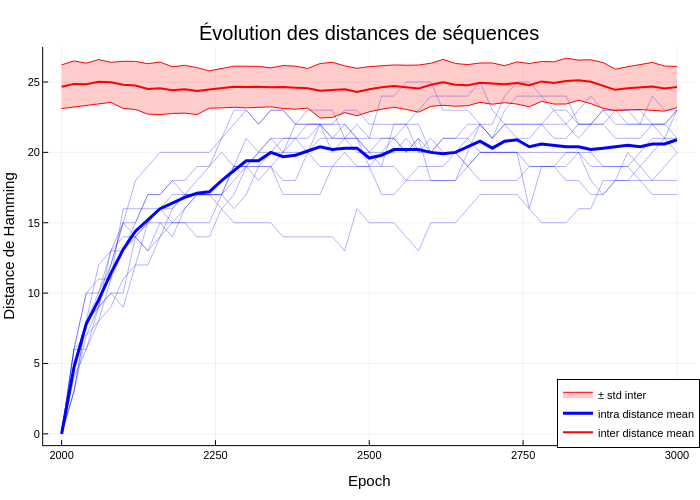

In [7]:
paths_reduced = reduce_data(PATHS, 10)
beta = 100.0

seq_over_time = multi_init_seq_over_time(target_number, all_ctc_maps, epochs=3000, beta=beta, threshold=2000, step=20, runs=10)
plot_distances_inter_intra(seq_over_time, beta=beta)

### All proba

In [8]:
final_seq, p_struct_time_t, p_final,_=algo_show_probability_distribution(seq, target_number, all_ctc_maps, 10000, 100)
show_sorted_indices(p_final)

algo (β=100) 100%|███████████████████████████████████████| Time: 0:00:06


structure 1234 : 0.9559982027965659
structure 1558 : 0.009140874261455795
structure 1243 : 0.004771954804096443
structure 532 : 0.0043178432639229885
structure 1233 : 0.0030427327213586827
structure 1244 : 0.0024911788523729874
structure 5089 : 0.0018455106848148694
structure 1797 : 0.0014372851665004679
structure 493 : 0.0013671879417736666
structure 1166 : 0.0009634410589749277
structure 529 : 0.0008717575202327185
structure 2332 : 0.0008717575202327178
structure 5138 : 0.0006789254394056243
structure 5123 : 0.0006143171416307145
structure 5072 : 0.0006143171416307136
structure 1113 : 0.0006143171416307079
structure 2732 : 0.000555857136288371
structure 1239 : 0.0004117890946583817
structure 5133 : 0.00037260218118605095
structure 3928 : 0.0003544301583773194


In [9]:
# Mutations en fonction de la position
paths_reduced = reduce_data(PATHS, 10)
seq = generate_seq()
target_number = 1234

all_ctc_maps = all_contact_maps(paths_reduced)

beta = 100

_, _, saved_seq = algo(seq, target_number, all_ctc_maps, 10000, beta, 2000, 200)
println("On a sauvegardé $(length(saved_seq)) structures.")

n_mutations_per_position = amount_of_mutations(saved_seq)
n_mutations_per_position


algo (β=100) 100%|███████████████████████████████████████| Time: 0:00:06


On a sauvegardé 41 structures.


Dict{Int64, Int64} with 27 entries:
  5  => 8
  16 => 10
  20 => 29
  12 => 14
  24 => 24
  8  => 14
  17 => 15
  1  => 35
  19 => 29
  23 => 20
  22 => 2
  6  => 32
  11 => 23
  9  => 5
  14 => 21
  3  => 26
  7  => 21
  25 => 1
  4  => 19
  ⋮  => ⋮

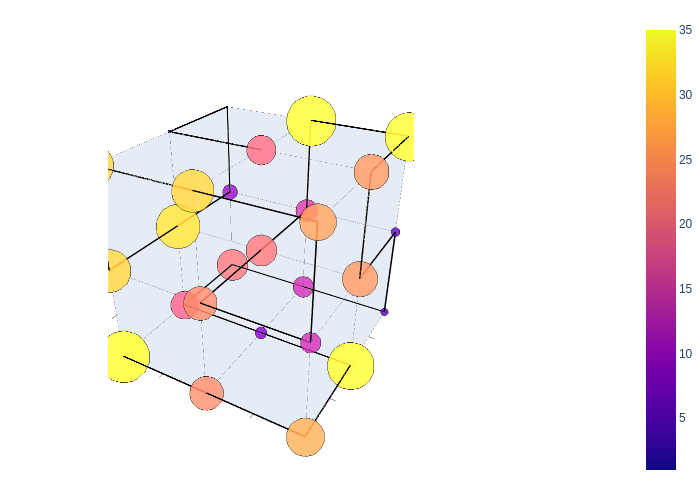

In [10]:
plot_cube_with_mutations_on_sphere(x, y, z, lx, ly, lz, PATHS[1234], n_mutations_per_position)

## Tree generation

In [11]:
paths_reduced = reduce_data(PATHS, 10)
seq = generate_seq()
target_number = 1234
all_ctc_maps = all_contact_maps(paths_reduced)

root_seq,_,_ = algo(seq, target_number, all_ctc_maps, 5000, 100, 10000, 200, true)
newick, seq_dict = create_genealogy(root_seq, 50, 2, target_number, all_ctc_maps)

println(newick)

# Charger l'arbre dans TreeTools
tree = parse_newick_string(newick)

for node in nodes(tree)
    name = label(node)
    println("$name : $(seq_dict[name])")
end

algo (β=100) 100%|███████████████████████████████████████| Time: 0:00:03


((N3:50,N4:50)N2:50,(N6:50,N7:50)N5:50)N1;
N3 : [3, 10, 19, 19, 19, 11, 15, 15, 6, 16, 2, 8, 6, 18, 16, 2, 11, 4, 13, 16, 19, 6, 12, 18, 3, 9, 15]
N4 : [18, 13, 20, 19, 19, 14, 15, 13, 6, 15, 3, 4, 2, 18, 15, 5, 10, 5, 19, 16, 19, 6, 17, 19, 5, 10, 14]
N5 : [1, 12, 7, 19, 19, 16, 15, 16, 9, 19, 6, 3, 3, 19, 16, 5, 18, 3, 15, 15, 19, 20, 17, 9, 3, 15, 12]
N7 : [11, 8, 8, 19, 19, 16, 15, 16, 5, 18, 6, 6, 4, 19, 12, 5, 17, 2, 15, 15, 18, 5, 15, 5, 4, 16, 13]
N1 : [20, 19, 5, 19, 19, 19, 15, 16, 3, 19, 9, 2, 6, 19, 16, 3, 10, 2, 15, 15, 19, 4, 11, 10, 4, 16, 12]
N6 : [14, 7, 9, 18, 19, 16, 15, 16, 2, 19, 11, 6, 2, 17, 16, 2, 10, 4, 15, 15, 19, 20, 18, 19, 7, 15, 15]
N2 : [13, 13, 5, 18, 19, 19, 15, 10, 3, 18, 7, 3, 5, 18, 16, 2, 10, 3, 15, 16, 19, 3, 18, 18, 5, 14, 16]


In [12]:
simple_print_distance_matrix(seq_dict)

      N3    N4    N5    N7    N1    N6    N2    
N3    0     19    21    24    21    20    19    
N4    19    0     21    23    22    21    19    
N5    21    21    0     17    16    16    20    
N7    24    23    17    0     17    20    23    
N1    21    22    16    17    0     18    18    
N6    20    21    16    20    18    0     18    
N2    19    19    20    23    18    18    0     


In [13]:
p = plot_distance_matrix(seq_dict)
savefig(p, "../figures/distance_matrix.svg")

"/home/gabriel/Documents/S2/Projet_BIM/pBIM/figures/distance_matrix.svg"

In [14]:
tree


                                        _____________________________________ N3
  _____________________________________|
 |                                     |_____________________________________ N4
_|
 |                                      _____________________________________ N6
 |_____________________________________|
                                       |_____________________________________ N7


In [22]:
result = fitch_reconstruction(tree, seq_dict)

for (name, seq) in sort(collect(result))
    println("$name : $(join(seq, " "))")
end

N1 : 11 13 20 19 19 16 15 13 5 16 6 4 2 18 16 5 10 4 13 16 19 5 15 19 5 15 15
N2 : 18 13 20 19 19 11 15 13 6 16 2 4 2 18 16 5 10 4 13 16 19 6 12 19 5 10 15
N3 : 3 10 19 19 19 11 15 15 6 16 2 8 6 18 16 2 11 4 13 16 19 6 12 18 3 9 15
N4 : 18 13 20 19 19 14 15 13 6 15 3 4 2 18 15 5 10 5 19 16 19 6 17 19 5 10 14
N5 : 11 7 9 19 19 16 15 16 5 18 6 6 2 17 16 5 10 4 15 15 19 5 15 19 4 15 15
N6 : 14 7 9 18 19 16 15 16 2 19 11 6 2 17 16 2 10 4 15 15 19 20 18 19 7 15 15
N7 : 11 8 8 19 19 16 15 16 5 18 6 6 4 19 12 5 17 2 15 15 18 5 15 5 4 16 13


In [16]:
@which root(tree)

root(t::Tree)
     @ TreeTools ~/.julia/packages/TreeTools/nIWnY/src/objects.jl:194

In [17]:
typeof(root)

typeof(root) (singleton type of function root, subtype of Function)